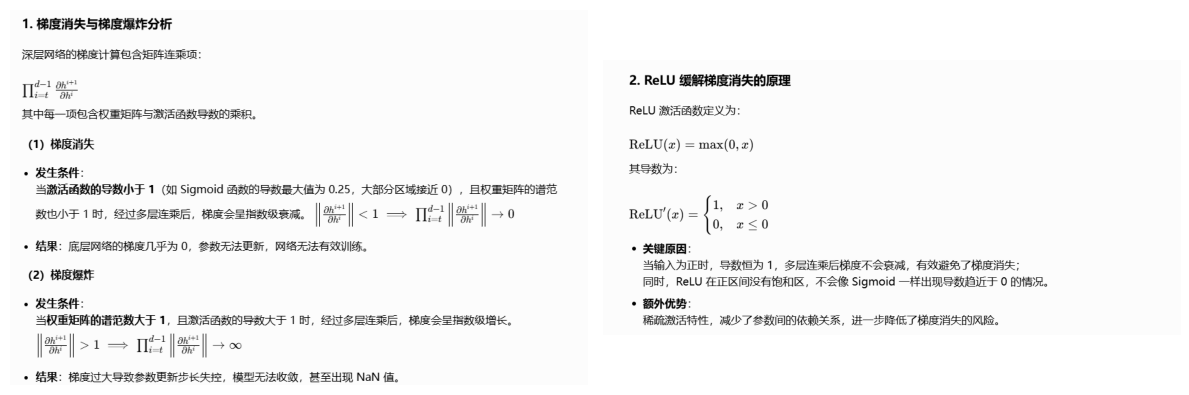

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

# 图片路径（路径格式没问题，不用改）
img_path = "C:/Users/86172/Desktop/Snipaste_2026-05-25_21-47-41.png"
img_path2 = "C:/Users/86172/Desktop/Snipaste_2026-05-25_21-51-55.png"

# 读取图片
img = Image.open(img_path)
img2 = Image.open(img_path2)

# 1. 创建一个画布，分成 1行2列 的布局
plt.figure(figsize=(12, 5))

# 第一张图：在第1个位置
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')  # 隐藏坐标轴

# 第二张图：在第2个位置
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis('off')

# 显示
plt.tight_layout()  # 自动调整间距，防止图片重叠
plt.show()

===== 实验1：Sigmoid + 普通高斯初始化 =====
层2 梯度范数: 6106.703613
层4 梯度范数: 4211.923340
层5 梯度范数: 3003.442383
层6 梯度范数: 2774.374756
层7 梯度范数: 2159.876221
层8 梯度范数: 1651.030396
层9 梯度范数: 1323.991943
层10 梯度范数: 958.307373
层11 梯度范数: 751.927734
层12 梯度范数: 580.511169
层13 梯度范数: 483.491333
层14 梯度范数: 397.817261
层15 梯度范数: 371.582581
层16 梯度范数: 312.122040
层17 梯度范数: 277.718506
层18 梯度范数: 291.993195
层19 梯度范数: 291.959259
层20 梯度范数: 369.714874
层21 梯度范数: 318.673615
层22 梯度范数: 318.218567

===== 实验2：ReLU + 大初始化std=10 =====
层2 梯度范数: nan
层4 梯度范数: inf
层5 梯度范数: inf
层6 梯度范数: inf
层7 梯度范数: inf
层8 梯度范数: inf
层9 梯度范数: inf
层10 梯度范数: inf
层11 梯度范数: inf
层12 梯度范数: inf
层13 梯度范数: inf
层14 梯度范数: inf
层15 梯度范数: inf
层16 梯度范数: inf
层17 梯度范数: inf
层18 梯度范数: inf
层19 梯度范数: inf
层20 梯度范数: inf
层21 梯度范数: inf
层22 梯度范数: nan

===== 实验3：ReLU + Xavier初始化 =====
层2 梯度范数: 5.344687
层4 梯度范数: 8.276194
层5 梯度范数: 9.901698
层6 梯度范数: 11.429564
层7 梯度范数: 12.107752
层8 梯度范数: 13.688300
层9 梯度范数: 14.553308
层10 梯度范数: 16.582052
层11 梯度范数: 16.852083
层12 梯度范数: 16.050840
层13 梯度范数: 15.0

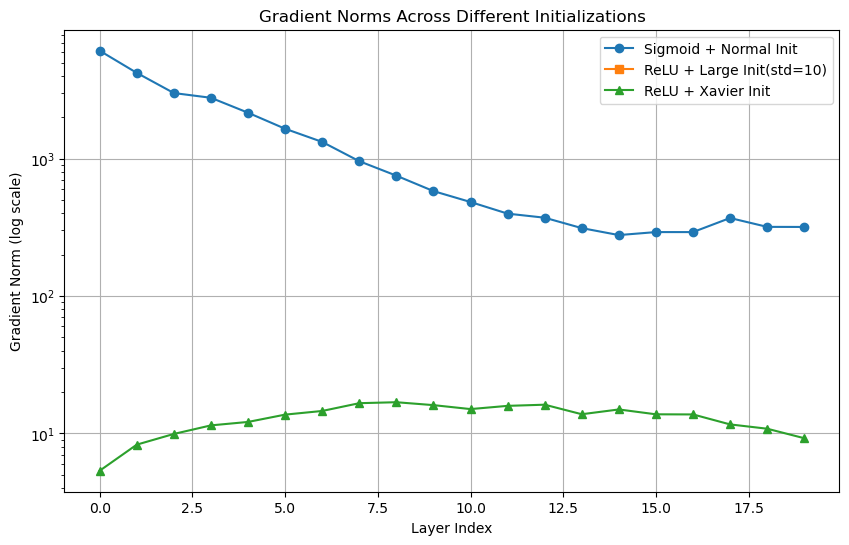

In [15]:
import torch
import torch.nn as nn
import torch.nn.init as init
import matplotlib.pyplot as plt

# ===================== 1. 构建20层深层全连接网络 =====================
def build_deep_network(activation_fn=nn.Sigmoid(), weight_init=None, std=1.0):
    layers = []
    # 输入层：假设输入维度为256
    layers.append(nn.Linear(256, 256))
    layers.append(activation_fn)
    
    # 隐藏层：共19层，总层数20
    for _ in range(19):
        layers.append(nn.Linear(256, 256))
        layers.append(activation_fn)
    
    model = nn.Sequential(*layers)
    
    # 权重初始化
    if weight_init is not None:
        for m in model.modules():
            if isinstance(m, nn.Linear):
                weight_init(m.weight)
                init.zeros_(m.bias)
    else:
        # 默认高斯初始化
        for m in model.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=std)
                init.zeros_(m.bias)
    return model

# ===================== 2. 计算并打印各层梯度范数 =====================
def compute_gradient_norms(model, x):
    # 前向传播
    out = model(x)
    # 反向传播（随机梯度）
    out.sum().backward()
    
    norms = []
    for i, m in enumerate(model.modules()):
        if isinstance(m, nn.Linear):
            grad_norm = m.weight.grad.norm().item()
            norms.append(grad_norm)
            print(f"层{i+1} 梯度范数: {grad_norm:.6f}")
    
    # 清空梯度
    model.zero_grad()
    return norms

# ===================== 3. 实验1：Sigmoid + 普通高斯初始化（梯度消失） =====================
print("===== 实验1：Sigmoid + 普通高斯初始化 =====")
model_sigmoid = build_deep_network(activation_fn=nn.Sigmoid(), std=1.0)
x = torch.randn(32, 256)  # 随机输入
norms_sigmoid = compute_gradient_norms(model_sigmoid, x)

# ===================== 4. 实验2：ReLU + 大初始化std=10（梯度爆炸/NaN） =====================
print("\n===== 实验2：ReLU + 大初始化std=10 =====")
model_relu_large = build_deep_network(activation_fn=nn.ReLU(), std=10.0)
norms_relu_large = compute_gradient_norms(model_relu_large, x)

# ===================== 5. 实验3：ReLU + Xavier初始化（梯度稳定） =====================
print("\n===== 实验3：ReLU + Xavier初始化 =====")
model_relu_xavier = build_deep_network(activation_fn=nn.ReLU(), 
                                       weight_init=init.xavier_uniform_)
norms_relu_xavier = compute_gradient_norms(model_relu_xavier, x)

# ===================== 6. 绘制梯度范数对比曲线 =====================
plt.figure(figsize=(10, 6))
plt.plot(norms_sigmoid, label='Sigmoid + Normal Init', marker='o')
plt.plot(norms_relu_large, label='ReLU + Large Init(std=10)', marker='s')
plt.plot(norms_relu_xavier, label='ReLU + Xavier Init', marker='^')

plt.yscale('log')  # 对数坐标，更易观察差异
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Gradient Norms Across Different Initializations')
plt.legend()
plt.grid(True)
plt.show()